**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**

---

# Sheet 7: Actionable Systems — Bayesian Decision Theory, Loss Functions & Predictive Checks
### *Closing the Loop from Posterior Distributions to Optimal Actions and Generative Validation*

Throughout Sheets 1 through 6, we mastered how to compute posterior distributions $p(\theta \mid D)$ across diverse modeling paradigms. However, an inference is not yet a decision: software systems, automated bots, and engineers must take discrete real-world actions.

In this capstone sheet, we formalize **Bayesian Decision Theory**: proving why the Posterior Mean, Median, and Mode (MAP) are optimal under $L_2$, $L_1$, and $0\text{-}1$ loss; deriving optimal asymmetric business cost cutoffs ($c^* = C_{\text{FP}} / (C_{\text{FP}} + C_{\text{FN}})$); and closing the workflow loop with **Prior and Posterior Predictive Checks (PPC)**.

---

---

## Table of Contents
1. **Part 1: The Formal Decision Framework**
   - Why Estimation is Only Half the Battle
   - States of Nature ($\Theta$), Action Space ($\mathcal{A}$), and Loss Matrices ($L(a, \theta)$)
   - Minimizing Posterior Expected Loss ($\mathbb{E}[L(a, \theta) \mid D]$)
2. **Part 2: Point Estimate Optimality Proofs ($L_2$, $L_1$, and $0\text{-}1$ Loss)**
   - Quadratic Loss ($L_2$) $\implies$ Posterior Mean
   - Linear / Absolute Loss ($L_1$) $\implies$ Posterior Median
   - $0\text{-}1$ Loss $\implies$ Posterior Mode (MAP)
   - Numerical Simulation & Loss Curve Minima
3. **Part 3: Asymmetric Engineering Loss — The Flaky Test Dilemma**
   - The Asymmetric Smoke Detector Metaphor
   - Cost of False Alarms ($C_{\text{FP}}$) vs. Cost of Missed Outages ($C_{\text{FN}}$)
   - Deriving the Optimal Decision Threshold $c^* = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}}$
4. **Part 4: Generative Validation — Prior & Posterior Predictive Checks (PPC)**
   - The Generative Reality Mirror Metaphor
   - Simulating 2,000 Synthetic CI Test Suites
   - Discrepancy Test Statistics & Posterior Predictive $p$-values ($\text{ppp}$)
5. **Part 5: The Production Bayesian Decision Engine**
   - Automated Quarantine Engine under Economic Uncertainty
   - Testing Across Production Scenarios (Heathy, Borderline, Catastrophic)
6. **Part 6: Check Your Understanding (3-Tier Scaffolding Exercises)**
   - 🟢 Tier 1 (Warm-Up): Autonomous Drone Collision Cutoffs
   - 🟡 Tier 2 (Guided Calculation): Why Mean vs. Median Matters under Skewed Costs
   - 🔴 Tier 3 (Production Challenge): Diagnosing Extreme Predictive $p$-values

---
## Part 1: The Formal Decision Framework

In scientific research or production engineering, computing $p(\theta \mid D)$ is only half the battle. Eventually, a software system or decision-maker must **choose an action** $a \in \mathcal{A}$:
- *Should we deploy this release candidate or abort?*
- *Should we automatically quarantine this flaky test or let developers merge?*
- *Should we scale our cluster from 10 to 50 nodes?*

### The Elements of Bayesian Decision Theory (Wald, 1950)
1. **Parameter Space $\Theta$**: The true, unobservable state of nature (e.g., flakiness rate $\theta \in [0, 1]$).
2. **Action Space $\mathcal{A}$**: The set of possible choices available to the agent (e.g., $a_0 = \text{Pass}$, $a_1 = \text{Quarantine}$).
3. **Loss Function $L(a, \theta): \mathcal{A} \times \Theta \to \mathbb{R}$**: The quantifiable penalty or regret incurred by choosing action $a$ when the true state turns out to be $\theta$.
4. **Posterior Expected Loss $\rho(a, p)$**:
   $$\rho(a, p) = \mathbb{E}_{\theta \sim p(\theta \mid D)} [L(a, \theta)] = \int_\Theta L(a, \theta) \, p(\theta \mid D) \, d\theta$$

### The Bayes Decision Criterion
The **Bayes Optimal Action** $a^*$ is the action that minimizes expected loss under the posterior:
$$a^* = \arg\min_{a \in \mathcal{A}} \rho(a, p) = \arg\min_{a \in \mathcal{A}} \mathbb{E}[L(a, \theta) \mid D]$$

---
## Part 2: Point Estimate Optimality Proofs ($L_2$, $L_1$, and $0\text{-}1$ Loss)

Often in reporting, stakeholders demand a **single number** summary of $\theta$ (a point estimate $\hat{\theta} \in \Theta$). Which summary should you report: the **Mean**, **Median**, or **Mode (MAP)**?

Decision theory provides the mathematically rigorous answer: **the optimal point estimate is completely determined by your loss function.**

---

### Theorem 1: $L_2$ Squared Error Loss $\implies$ Posterior Mean
Let $L(a, \theta) = (a - \theta)^2$. The expected loss is:
$$\rho(a) = \int (a - \theta)^2 p(\theta \mid D) \, d\theta = a^2 - 2a \mathbb{E}[\theta \mid D] + \mathbb{E}[\theta^2 \mid D]$$
Differentiating with respect to $a$ and setting to zero:
$$\frac{d\rho}{da} = 2a - 2\mathbb{E}[\theta \mid D] = 0 \implies a^* = \mathbb{E}[\theta \mid D]$$
> **Result**: The **Posterior Mean** is the unique Bayes optimal point estimate if and only if errors penalize quadratically.

---

### Theorem 2: $L_1$ Absolute Error Loss $\implies$ Posterior Median
Let $L(a, \theta) = |a - \theta|$. The expected loss is:
$$\rho(a) = \int_{-\infty}^a (a - \theta) p(\theta \mid D) \, d\theta + \int_a^\infty (\theta - a) p(\theta \mid D) \, d\theta$$
Differentiating with respect to $a$ using Leibniz's rule:
$$\frac{d\rho}{da} = \int_{-\infty}^a p(\theta \mid D) \, d\theta - \int_a^\infty p(\theta \mid D) \, d\theta = 0$$
$$\implies P(\theta \le a^* \mid D) = P(\theta > a^* \mid D) = \frac{1}{2}$$
> **Result**: The **Posterior Median** is the unique Bayes optimal point estimate if and only if errors penalize linearly (robust to extreme outliers).

---

### Theorem 3: $0\text{-}1$ Loss $\implies$ Posterior Mode (MAP)
Let $L(a, \theta) = -\delta(a - \theta)$ (infinitesimal zero-loss tolerance around $\theta$).
$$\rho(a) = -p(a \mid D) \implies a^* = \arg\max_a p(a \mid D)$$
> **Result**: The **Posterior Mode (MAP)** is optimal only if you receive credit solely for an exact bullseye and penalize all near-misses equally.

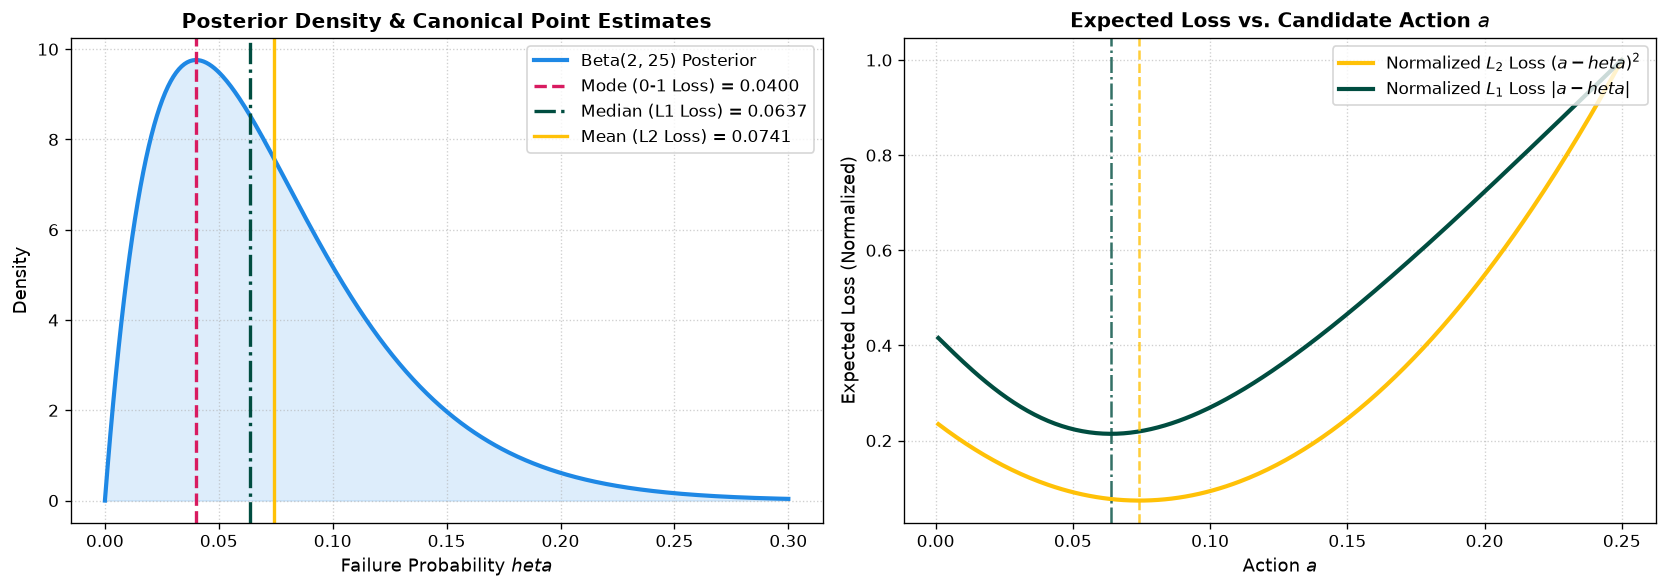

--- Theoretical vs Empirical Minimizers ---
Theoretical Mean   (L2): 0.07407 | Empirical Minimum: 0.07428
Theoretical Median (L1): 0.06372 | Empirical Minimum: 0.06429
Theoretical Mode   (L0): 0.04000


In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Consider a skewed posterior for a rare failure rate: Beta(alpha=2, beta=25)
alpha_post, beta_post = 2, 25
theta_dist = stats.beta(alpha_post, beta_post)

# Theoretical point estimates
post_mean = alpha_post / (alpha_post + beta_post)
post_median = theta_dist.ppf(0.5)
post_mode = (alpha_post - 1) / (alpha_post + beta_post - 2)

# Candidate actions across the domain
a_grid = np.linspace(0.001, 0.25, 300)

# Generate 100,000 posterior draws to compute empirical expected loss
np.random.seed(42)
posterior_samples = theta_dist.rvs(size=100_000)

# Compute expected loss curves
loss_squared = [np.mean((a - posterior_samples)**2) for a in a_grid]
loss_absolute = [np.mean(np.abs(a - posterior_samples)) for a in a_grid]

# Minima of empirical curves
opt_squared = a_grid[np.argmin(loss_squared)]
opt_absolute = a_grid[np.argmin(loss_absolute)]

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Panel 1: Posterior density with point estimates
x = np.linspace(0, 0.3, 500)
ax1.plot(x, theta_dist.pdf(x), color="#1E88E5", lw=2.5, label="Beta(2, 25) Posterior")
ax1.fill_between(x, 0, theta_dist.pdf(x), color="#1E88E5", alpha=0.15)
ax1.axvline(post_mode, color="#D81B60", lw=2, linestyle="--", label=f"Mode (0-1 Loss) = {post_mode:.4f}")
ax1.axvline(post_median, color="#004D40", lw=2, linestyle="-.", label=f"Median (L1 Loss) = {post_median:.4f}")
ax1.axvline(post_mean, color="#FFC107", lw=2, linestyle="-", label=f"Mean (L2 Loss) = {post_mean:.4f}")
ax1.set_title("Posterior Density & Canonical Point Estimates", fontsize=12, fontweight="bold")
ax1.set_xlabel("Failure Probability $\theta$", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Panel 2: Expected loss curves
ax2.plot(a_grid, loss_squared / np.max(loss_squared), color="#FFC107", lw=2.5, label="Normalized $L_2$ Loss $(a - \theta)^2$")
ax2.plot(a_grid, loss_absolute / np.max(loss_absolute), color="#004D40", lw=2.5, label="Normalized $L_1$ Loss $|a - \theta|$")
ax2.axvline(post_mean, color="#FFC107", lw=1.5, linestyle="--", alpha=0.8)
ax2.axvline(post_median, color="#004D40", lw=1.5, linestyle="-.", alpha=0.8)
ax2.set_title("Expected Loss vs. Candidate Action $a$", fontsize=12, fontweight="bold")
ax2.set_xlabel("Action $a$", fontsize=11)
ax2.set_ylabel("Expected Loss (Normalized)", fontsize=11)
ax2.legend(loc="upper right", frameon=True)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"--- Theoretical vs Empirical Minimizers ---")
print(f"Theoretical Mean   (L2): {post_mean:.5f} | Empirical Minimum: {opt_squared:.5f}")
print(f"Theoretical Median (L1): {post_median:.5f} | Empirical Minimum: {opt_absolute:.5f}")
print(f"Theoretical Mode   (L0): {post_mode:.5f}")

---
## Part 3: Asymmetric Engineering Loss — The Flaky Test Dilemma

In real-world engineering, symmetric losses ($L_1, L_2$) are rarely appropriate. Costs are drastically asymmetric:



### The Asymmetric Smoke Detector: Why 50% is Lethal

Why does a household smoke detector beep when you burn a piece of toast?
Because the underlying cost matrix is profoundly asymmetric:
- **Cost of False Positive (Burnt Toast)**: $\approx 0\text{ USD}$ (waving a dishtowel for 30 seconds; a minor annoyance).
- **Cost of False Negative (House Fire)**: $\infty$ (catastrophic destruction of property and loss of human life).

A smoke detector engineered with a "symmetric" $50\%$ probability threshold would kill millions of people! Because a missed fire is infinitely worse than a false alarm, the Bayes-optimal decision rule demands triggering the alarm when fire probability is merely $0.1\%$.

| Loss Regime | Cost Structure | Optimal Decision Boundary |
| :--- | :--- | :--- |
| **Symmetric Loss**<br>*(Textbook Myth)* | $C(\text{False Alarm}) = C(\text{Missed Fire})$<br>Treats false alarms and catastrophic fires as equally costly. | Default threshold: **$p^* = 0.50$** (50%). Completely reckless in mission-critical applications. |
| **Asymmetric Loss**<br>*(Production Reality)* | $C(\text{False Alarm}) \ll C(\text{Missed Fire})$<br>Burnt toast costs `$150` in nuisance; an undetected house fire costs millions in catastrophic damage. | Bayes-optimal threshold: **$p^* = \frac{C_{\text{FP}}}{C_{\text{FP}} + C_{\text{FN}}} \approx 0.001$** ($0.1\%$). |

In software engineering, CI/CD test quarantine operates under the identical asymmetric math:
- **Action $a_0$ (Pass Test)**: If the test was actually flaky, a broken commit merges into `main`, breaking the build for $50$ engineers and costing thousands of dollars in lost velocity ($C_{\text{FN}} = 2{,}000\text{ USD}$).
- **Action $a_1$ (Quarantine Test)**: If the test was actually healthy, a developer spends $1$ hour investigating a false alarm ($C_{\text{FP}} = 150\text{ USD}$).

### The Production Scenario
Suppose a test in your automated CI pipeline has an unobserved failure probability $\theta$.
- **Definition of "Flaky"**: A test is considered unacceptably flaky if $\theta > \theta_{\text{crit}} = 0.05$ (5% failure rate).
- **Available Actions**:
  - $a_0$: **Pass / Do Nothing** (Keep test active in CI).
  - $a_1$: **Quarantine** (Remove test from the merge-blocking path and alert on-call).

### The Cost Matrix
| True State | Action $a_0$ (Pass) | Action $a_1$ (Quarantine) |
| :--- | :--- | :--- |
| **Healthy** ($\theta \le 0.05$) | **`$0`** (All clear) | **$C_{\text{triage}} = 150\text{ USD}$** (Wasted engineering time to investigate) |
| **Flaky** ($\theta > 0.05$) | **$C_{\text{incident}} = 5{,}000\text{ USD}$** (Broken builds, delayed merges, release rollbacks) | **$C_{\text{triage}} = 150\text{ USD}$** (Triage cost to fix test) |

---

### Derivation of the Optimal Decision Threshold $c^*$
Let $p_{\text{flaky}} = P(\theta > 0.05 \mid D)$ be the posterior probability that the test is flaky.

1. **Expected Loss of Action $a_1$ (Quarantine)**:
   $$\mathbb{E}[L(a_1)] = C_{\text{triage}} = 150\text{ USD}$$

2. **Expected Loss of Action $a_0$ (Pass)**:
   $$\mathbb{E}[L(a_0)] = p_{\text{flaky}} \cdot C_{\text{incident}} + (1 - p_{\text{flaky}}) \cdot 0 = p_{\text{flaky}} \cdot 5{,}000\text{ USD}$$

3. **Optimal Decision Rule**:
   Quarantine if and only if $\mathbb{E}[L(a_1)] < \mathbb{E}[L(a_0)]$:
   $$C_{\text{triage}} < p_{\text{flaky}} \cdot C_{\text{incident}} \implies p_{\text{flaky}} > \frac{C_{\text{triage}}}{C_{\text{incident}}} = \frac{150}{5000} = 0.03$$

> 💡 **The Core Lesson**: You should quarantine when there is only a **3% probability** that the test is flaky! 
> A naive engineer waiting for a $50\%$ majority vote or a $95\%$ confidence interval would incur massive financial losses.


<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\$'
<>:18: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\m'
C:\Users\tarob\AppData\Local\Temp\ipykernel_19532\2461784582.py:17: SyntaxWarning: invalid escape sequence '\$'
  plt.plot(p_grid * 100, loss_pass, color="#D81B60", lw=2.5, label="Expected Cost: Pass $a_0$ ($p \times \$5,000$)")
C:\Users\tarob\AppData\Local\Temp\ipykernel_19532\2461784582.py:18: SyntaxWarning: invalid escape sequence '\$'
  plt.plot(p_grid * 100, loss_quarantine, color="#1E88E5", lw=2.5, linestyle="--", label="Expected Cost: Quarantine $a_1$ (Flat $\$150$)")
C:\Users\tarob\AppData\Local\Temp\ipykernel_19532\2461784582.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Posterior Probability of Flakiness $P(\theta > 0.05 \mid D)$ (%)", fontsize=11)


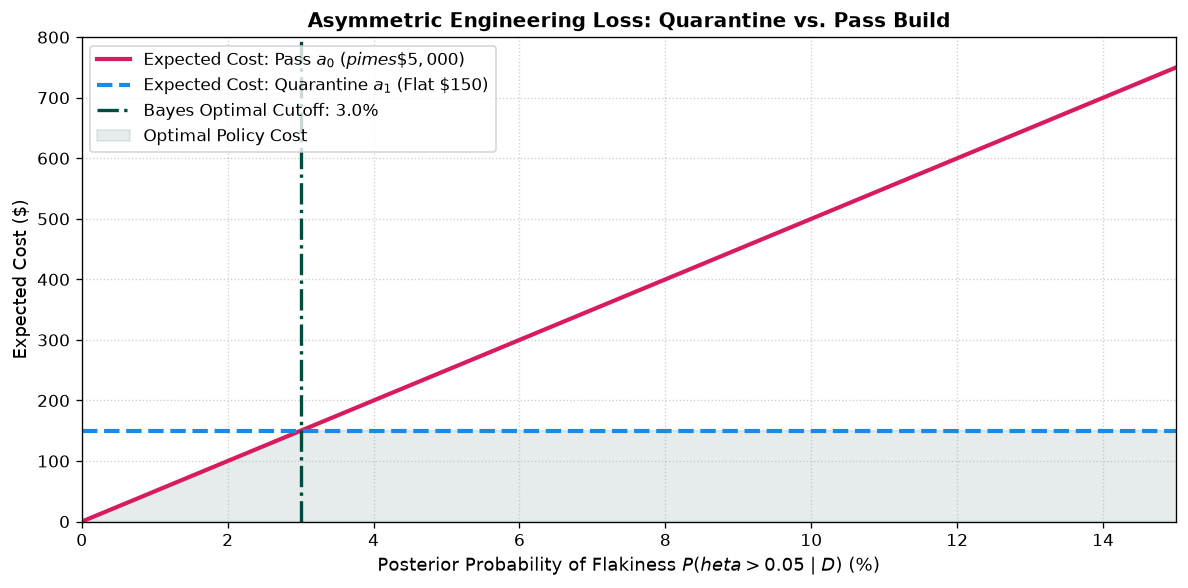

Optimal Quarantine Threshold: P(flaky) > 3.0%
At P(flaky) = 10%: Expected cost of Pass = $500.00 vs Quarantine = $150.00
Net savings per test decision by using Bayes Policy: $350.00


In [2]:
# Economic parameters
C_triage = 150        # Cost of developer investigating a false alarm ($)
C_incident = 5000     # Cost of flaky test disrupting engineering ($)
optimal_threshold = C_triage / C_incident  # 0.03

# Probability grid of p_flaky
p_grid = np.linspace(0, 0.20, 200)

# Expected loss functions ($)
loss_pass = p_grid * C_incident
loss_quarantine = np.full_like(p_grid, C_triage)

# Naive threshold (50% probability) vs Bayesian threshold (3%)
naive_threshold = 0.50

plt.figure(figsize=(10, 5), dpi=120)
plt.plot(p_grid * 100, loss_pass, color="#D81B60", lw=2.5, label="Expected Cost: Pass $a_0$ ($p \times \$5,000$)")
plt.plot(p_grid * 100, loss_quarantine, color="#1E88E5", lw=2.5, linestyle="--", label="Expected Cost: Quarantine $a_1$ (Flat $\$150$)")
plt.axvline(optimal_threshold * 100, color="#004D40", lw=2, linestyle="-.", label=f"Bayes Optimal Cutoff: {optimal_threshold*100:.1f}%")

# Fill regions
plt.fill_between(p_grid * 100, 0, np.minimum(loss_pass, loss_quarantine), color="#004D40", alpha=0.1, label="Optimal Policy Cost")

plt.title("Asymmetric Engineering Loss: Quarantine vs. Pass Build", fontsize=12, fontweight="bold")
plt.xlabel("Posterior Probability of Flakiness $P(\theta > 0.05 \mid D)$ (%)", fontsize=11)
plt.ylabel("Expected Cost ($)", fontsize=11)
plt.xlim(0, 15)
plt.ylim(0, 800)
plt.legend(loc="upper left", frameon=True)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

print(f"Optimal Quarantine Threshold: P(flaky) > {optimal_threshold*100:.1f}%")
print(f"At P(flaky) = 10%: Expected cost of Pass = ${0.10 * C_incident:,.2f} vs Quarantine = ${C_triage:,.2f}")
print(f"Net savings per test decision by using Bayes Policy: ${0.10 * C_incident - C_triage:,.2f}")

---
## Part 4: Generative Validation — Prior & Posterior Predictive Checks

A model can compute an exact mathematical posterior, yet still be catastrophically wrong about the physical world. 
**Predictive Checks** test whether your model can simulate realistic data.

```
          ┌────────────────────────────────────────────────────────┐
          │               THE BAYESIAN GENERATIVE LOOP             │
          │                                                        │
          │  1. Priors p(θ) ───────────► Prior Predictive Check    │
          │        │                            │                  │
          │        ▼                            ▼                  │
          │  2. Data (D)  ─────────────► Posterior p(θ|D)          │
          │                                     │                  │
          │                                     ▼                  │
          │  3. Replications y^rep ────► Posterior Predictive Check│
          └────────────────────────────────────────────────────────┘
```

---

### 1. Prior Predictive Checks (Sanity Checking Your Assumptions)
Before collecting any data, draw parameter values from your prior, and simulate synthetic datasets:
$$\theta^{(s)} \sim p(\theta), \quad y^{(s)} \sim p(y \mid \theta^{(s)})$$
If your prior allows 500% failure rates or negative response times, your prior is encoding impossible physics and must be regularized.

---

### 2. Posterior Predictive Checks (Model Adequacy)
After computing $p(\theta \mid D)$, generate $S$ replicated datasets $y^{\text{rep}}$ of the exact same size as the observed data $y^{\text{obs}}$:
$$\theta^{(s)} \sim p(\theta \mid D), \quad y^{\text{rep},(s)} \sim p(y \mid \theta^{(s)})$$
Then choose a **test statistic** $T(y)$ that captures an aspect of the data you care about (e.g., maximum streak of consecutive failures, variance-to-mean ratio).

#### The Bayesian Posterior Predictive p-value (ppp)
$$\text{ppp} = P(T(y^{\text{rep}}) \ge T(y^{\text{obs}}) \mid D) = \frac{1}{S} \sum_{s=1}^S \mathbf{1}_{\{T(y^{\text{rep},(s)}) \ge T(y^{\text{obs}})\}}$$
- **$\text{ppp} \approx 0.50$**: The model reproduces this feature of reality with perfect balance.
- **$\text{ppp} < 0.02$ or $\text{ppp} > 0.98$**: The model is misspecified for this feature (e.g., failing to model clustering or temporal dependence).

### The Generative Reality Mirror: Can Your Model Hallucinate Real Data?

A model can output razor-thin credible intervals ($95\%\text{ CI}: [0.038, 0.042]$) and still be completely delusional about physical reality.

How do we catch a confident, broken model? We hold up a **Generative Reality Mirror**:
1. We ask the model: *"If your posterior beliefs are true, simulate $2,000$ synthetic test suites for next week."*
2. We compute a summary discrepancy statistic on the synthetic datasets—such as the **maximum streak of consecutive failures**—and compare it against the real historical CI log.
3. If the model's simulated universes produce max streaks of $2$ failures, but real CI logs routinely see bursts of $8$ consecutive network timeouts, **the model is broken**. Its binomial independence assumption has failed.

> [!IMPORTANT]
> **The Golden Rule of Generative Modeling**: If your model cannot generate synthetic data that looks indistinguishable from real data, its parameter estimates and credible intervals cannot be trusted for real decisions!

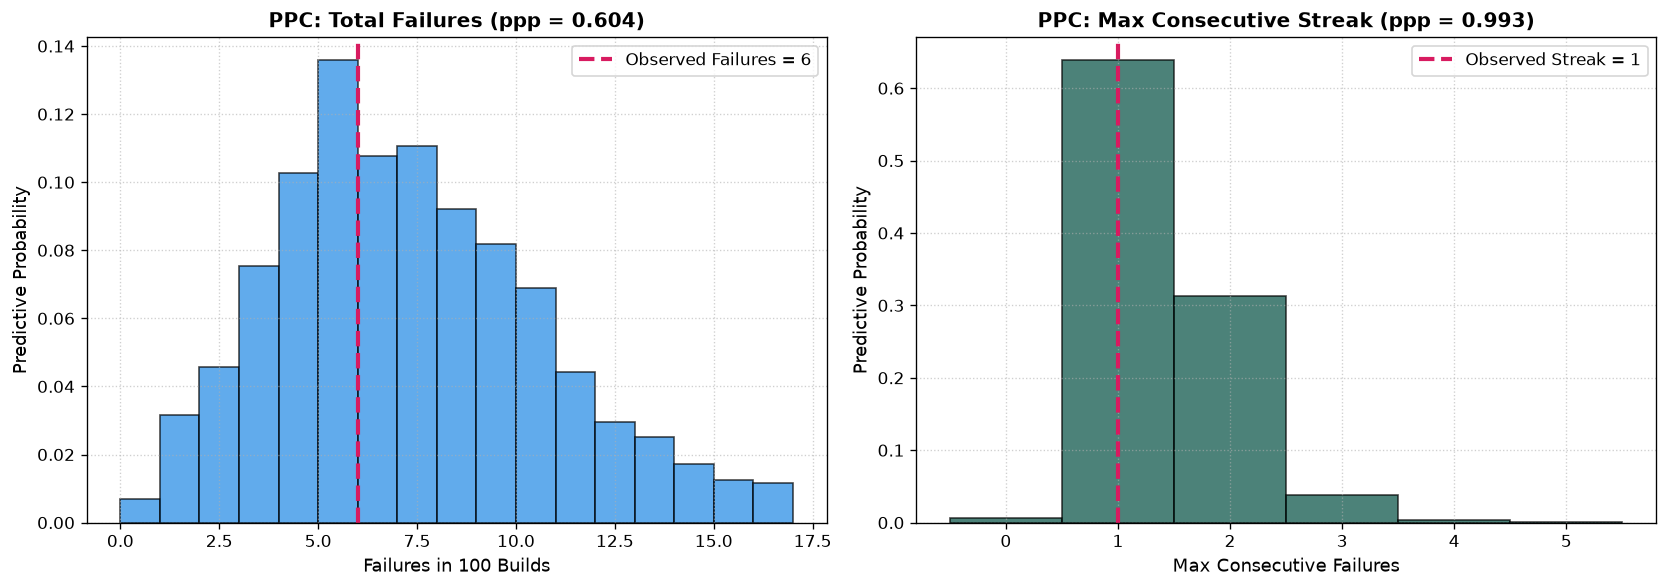

Posterior Predictive Check Summary:
- Observed Failures: 6 | Mean Replicated Failures: 6.88 (ppp = 0.604)
- Observed Streak:   1 | Mean Replicated Streak:   1.39 (ppp = 0.993)


In [3]:
# Step 1: Observed CI test suite data (100 builds, 6 failures observed)
n_builds = 100
k_failures_obs = 6
y_obs = np.array([1]*k_failures_obs + [0]*(n_builds - k_failures_obs))
np.random.shuffle(y_obs)

# Metric of interest: Maximum streak of consecutive failures
def max_streak(binary_array):
    max_s, current_s = 0, 0
    for val in binary_array:
        if val == 1:
            current_s += 1
            max_s = max(max_s, current_s)
        else:
            current_s = 0
    return max_s

t_obs_streak = max_streak(y_obs)

# Step 2: Posterior distribution: Beta(1 + 6, 1 + 94) = Beta(7, 95)
a_prior, b_prior = 1, 1
a_post, b_post = a_prior + k_failures_obs, b_prior + (n_builds - k_failures_obs)

# Step 3: Draw 2,000 replicated datasets from the posterior predictive distribution
S = 2000
np.random.seed(123)
theta_draws = stats.beta(a_post, b_post).rvs(size=S)

# Generate synthetic 100-build datasets
y_rep_failures = np.zeros(S)
y_rep_streaks = np.zeros(S)

for s in range(S):
    y_rep = np.random.binomial(n=1, p=theta_draws[s], size=n_builds)
    y_rep_failures[s] = np.sum(y_rep)
    y_rep_streaks[s] = max_streak(y_rep)

# Step 4: Compute posterior predictive p-values
ppp_failures = np.mean(y_rep_failures >= k_failures_obs)
ppp_streaks = np.mean(y_rep_streaks >= t_obs_streak)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# Panel 1: Replicated total failures vs Observed
ax1.hist(y_rep_failures, bins=range(0, 18), color="#1E88E5", alpha=0.7, edgecolor="black", density=True)
ax1.axvline(k_failures_obs, color="#D81B60", lw=2.5, linestyle="--", label=f"Observed Failures = {k_failures_obs}")
ax1.set_title(f"PPC: Total Failures (ppp = {ppp_failures:.3f})", fontsize=12, fontweight="bold")
ax1.set_xlabel("Failures in 100 Builds", fontsize=11)
ax1.set_ylabel("Predictive Probability", fontsize=11)
ax1.legend(loc="upper right", frameon=True)
ax1.grid(True, linestyle=":", alpha=0.6)

# Panel 2: Replicated max streak vs Observed
bins_streak = np.arange(0, np.max(y_rep_streaks) + 2) - 0.5
ax2.hist(y_rep_streaks, bins=bins_streak, color="#004D40", alpha=0.7, edgecolor="black", density=True)
ax2.axvline(t_obs_streak, color="#D81B60", lw=2.5, linestyle="--", label=f"Observed Streak = {t_obs_streak}")
ax2.set_title(f"PPC: Max Consecutive Streak (ppp = {ppp_streaks:.3f})", fontsize=12, fontweight="bold")
ax2.set_xlabel("Max Consecutive Failures", fontsize=11)
ax2.set_ylabel("Predictive Probability", fontsize=11)
ax2.legend(loc="upper right", frameon=True)
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Posterior Predictive Check Summary:")
print(f"- Observed Failures: {k_failures_obs} | Mean Replicated Failures: {np.mean(y_rep_failures):.2f} (ppp = {ppp_failures:.3f})")
print(f"- Observed Streak:   {t_obs_streak} | Mean Replicated Streak:   {np.mean(y_rep_streaks):.2f} (ppp = {ppp_streaks:.3f})")

---
## Part 5: The Production Bayesian Decision Engine

Below is a production-grade automated quarantine engine combining:
1. **Conjugate Beta updating** on real-time CI test runs.
2. **Asymmetric economic loss evaluation** over candidate actions ($a_0 = \text{Pass}, a_1 = \text{Quarantine}$).
3. **Automated policy decision** with financial risk audit logging.

In [4]:
def evaluate_test_quarantine_policy(k_failures, n_runs, 
                                     c_triage=150.0, 
                                     c_incident=5000.0, 
                                     flaky_threshold=0.05,
                                     prior_a=1.0, prior_b=1.0):
    """
    Computes Bayes Optimal Action for CI Test Quarantine under asymmetric loss.
    """
    # Posterior Beta parameters
    a_post = prior_a + k_failures
    b_post = prior_b + (n_runs - k_failures)
    
    # Probability of being flaky (exceeding flaky threshold)
    # P(theta > flaky_threshold) = 1 - CDF(flaky_threshold) = SF(flaky_threshold)
    p_flaky = stats.beta.sf(flaky_threshold, a_post, b_post)
    
    # Expected loss for each candidate action
    loss_pass = p_flaky * c_incident
    loss_quarantine = c_triage
    
    # Optimal action and threshold
    optimal_cutoff = c_triage / c_incident
    action = "QUARANTINE" if p_flaky > optimal_cutoff else "PASS"
    savings = abs(loss_pass - loss_quarantine)
    
    return {
        "runs": n_runs,
        "failures": k_failures,
        "post_mean_theta": a_post / (a_post + b_post),
        "p_flaky": p_flaky,
        "optimal_cutoff": optimal_cutoff,
        "expected_cost_pass": loss_pass,
        "expected_cost_quarantine": loss_quarantine,
        "recommended_action": action,
        "net_expected_savings": savings
    }

# Test across 3 production scenarios
scenarios = [
    {"name": "Stable Test", "k": 0, "n": 80},
    {"name": "Suspicious Early Warning", "k": 3, "n": 50},
    {"name": "Confirmed Toxic Flake", "k": 9, "n": 100}
]

print(f"{'Scenario':<25} | {'Runs':<5} | {'Failures':<8} | {'P(Flaky)':<10} | {'Action':<11} | {'Expected Risk'}")
print("-" * 80)
for sc in scenarios:
    res = evaluate_test_quarantine_policy(sc["k"], sc["n"])
    chosen_cost = res["expected_cost_quarantine"] if res["recommended_action"] == "QUARANTINE" else res["expected_cost_pass"]
    print(f"{sc['name']:<25} | {res['runs']:<5} | {res['failures']:<8} | {res['p_flaky']*100:>7.2f}%  | {res['recommended_action']:<11} | ${chosen_cost:>7.2f}")

Scenario                  | Runs  | Failures | P(Flaky)   | Action      | Expected Risk
--------------------------------------------------------------------------------
Stable Test               | 80    | 0        |    1.57%  | PASS        | $  78.45
Suspicious Early Warning  | 50    | 3        |   74.94%  | QUARANTINE  | $ 150.00
Confirmed Toxic Flake     | 100   | 9        |   97.01%  | QUARANTINE  | $ 150.00


## 🎯 Check Your Understanding: 3-Tier Scaffolding Exercises

Sharpen your intuition and practice the mathematical concepts introduced in this sheet. Write your solutions in the interactive attempt cells below before expanding the verified solutions.

---

### 🟢 Tier 1 (Warm-Up): Asymmetric Decision Cutoffs in Safety Systems
> **Scenario**: An autonomous drone collision prevention system has two actions: $a_0 = \text{Maintain Course}$ and $a_1 = \text{Emergency Brake}$. 
> If it brakes unnecessarily (False Positive), it costs `$10` in lost battery efficiency. If it fails to brake when an obstacle exists (False Negative), the crash costs `$10,000`.
> What is the Bayes optimal collision probability threshold $c^*$ at which the drone must hit the brakes?

In [ ]:
# ============================================================
# 🟢 Tier 1: Your Turn — Attempt the Problem Here
# ============================================================
cost_false_positive = 10.0     # cost of unnecessary braking
cost_false_negative = 10_000.0 # cost of crash if obstacle exists

# Bayes optimal threshold:
# Brake if E[L(brake)] < E[L(maintain)]
# c_star = ...

# print(f"Optimal Collision Threshold: {c_star:.4%}")


<details>
<summary><b>🔍 Click here to view the solution & mathematical derivation</b></summary>

**Answer**: $c^* = 0.1\%$ (or $p > 0.001$).

**Derivation**:
$$\mathbb{E}[L(a_1)] = 10\text{ USD}$$
$$\mathbb{E}[L(a_0)] = p \cdot 10{,}000\text{ USD}$$
Brake if:
$$\mathbb{E}[L(a_1)] < \mathbb{E}[L(a_0)] \implies 10 < p \cdot 10{,}000 \implies p > \frac{10}{10{,}000} = 0.001 = 0.1\%$$
Waiting until you are even $1\%$ or $5\%$ confident of a collision would be catastrophic negligence.
</details>

---

### 🟡 Tier 2 (Guided Calculation): Why Mean vs. Median Matters in Production SLAs
> **Scenario**: A database query latency posterior is log-normal with a heavy right tail:
> - Posterior Median = $15\text{ ms}$
> - Posterior Mean = $85\text{ ms}$
> - Posterior Mode (MAP) = $8\text{ ms}$
>
> If your client SLA contract penalizes you linearly for the absolute error of your latency forecast ($L_1 = |a - \theta|$), which point estimate should you commit to in the SLA to minimize expected penalties?

In [ ]:
# ============================================================
# 🟡 Tier 2: Your Turn — Attempt the Problem Here
# ============================================================
median_latency = 15.0
mean_latency = 85.0
mode_latency = 8.0

# Under L1 loss L(a, theta) = |a - theta|:
# Which estimate is the Bayes optimal point prediction?
optimal_prediction = None  # median_latency, mean_latency, or mode_latency

# Write your rationale below:


<details>
<summary><b>🔍 Click here to view the solution & optimality proof</b></summary>

**Answer**: Commit to the **Median ($15\text{ ms}$)**.

**Derivation**:
By Theorem 2, the Bayes optimal point estimate for $L_1$ absolute error loss $L(a, \theta) = |a - \theta|$ is strictly the **Posterior Median**. 
Reporting the Mean ($85\text{ ms}$) would minimize squared penalties ($L_2$), which over-penalizes rare extreme tail spikes and artificially inflates your linear SLA forecast error. Reporting the Mode ($8\text{ ms}$) would maximize point-density ($0\text{-}1$ loss), which ignores the magnitude of all misses.
</details>

---

### 🔴 Tier 3 (Production Challenge): Interpreting Extreme Posterior Predictive p-values
> **Scenario**: You run a posterior predictive check on 1,000 simulated test suites generated from your posterior $p(\theta \mid D)$. 
> You choose the discrepancy statistic $T(y) = \text{Maximum Consecutive Failure Streak}$.
> - Observed data streak: $T(y^{\text{obs}}) = 5\text{ consecutive failures}$.
> - Across all 1,000 replicated datasets, $T(y^{\text{rep}})$ never exceeds $2$ (yielding an empirical $\text{ppp} = 0.000$).
>
> 1. What does this diagnose about your standard independent Bernoulli/Binomial model?
> 2. What underlying physical phenomenon in software engineering causes this failure?
> 3. What model architecture resolves it?

In [ ]:
# ============================================================
# 🔴 Tier 3: Your Turn — Attempt the Problem Here
# ============================================================
t_obs = 5  # observed failure streak
t_rep_max = 2  # max streak across all 1,000 posterior replications

# ppp = np.mean(t_rep >= t_obs) = 0.000
# 1. What does ppp = 0.000 diagnose about an independent Binomial model?
# 2. What real-world phenomenon causes clustered failures in software tests?
# 3. What Bayesian model architectures handle overdispersion / temporal clustering?


<details>
<summary><b>🔍 Click here to view the model diagnostic & resolution</b></summary>

**Diagnosis & Resolution**:
1. **Model Failure (Overdispersion & Clustering)**: A $\text{ppp} = 0.000$ indicates that the observed failure streak of 5 is virtually impossible under the fitted independent Binomial model. The model is severely misspecified for temporal clustering.
2. **Physical Phenomenon**: In software engineering, test failures are rarely independent coin flips. A bad merge, broken Docker dependency, or external database outage causes **failure bursts** where consecutive runs fail together until a fix is deployed.
3. **Model Resolution**: 
   - Upgrade from standard Binomial to a **Beta-Binomial mixture model** (which models overdispersion).
   - Use a **Dynamic State-Space Model with Memory Decay** (Sheet 6) to model time-varying failure states.
</details>

---
**[🏠 Course Home](00_START_HERE.ipynb) | ⏮️ Previous: [Sheet 6: Dynamic Filtering — Calibrating Memory Decay (gamma)](06_calibrating_bayesian_decay_and_memory.ipynb)**